# Import Basic Python Libraries

In [1]:
# Basic Python libraries
import os  # For working with files and folders
import numpy as np  # For number operations
import pandas as pd  # For data handling

import warnings  # To hide warning messages
warnings.filterwarnings('ignore')  # Ignore warnings

In [2]:
# Visualization libraries
import matplotlib.pyplot as plt  # For creating plots
import seaborn as sns  # For better looking plots
from PIL import Image  # For working with images
import random  # For random operations

In [3]:
# Set random seeds so results are reproducible
np.random.seed(42)  # Same random numbers every time
random.seed(42)

  # Download Dataset from Kaggle

In [4]:
# Download dataset using kagglehub
import kagglehub

In [5]:
# Download latest version
path = kagglehub.dataset_download("techsash/waste-classification-data")
print(f"Dataset downloaded to: {path}")

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset downloaded to: /kaggle/input/waste-classification-data


# Load and Explore Dataset

In [6]:
# Check folder structure
print("Checking folder structure...")
print("Root folder contents:", os.listdir(path))
print("DATASET folder contents:", os.listdir(path+"/DATASET"))
print("Train folder contents:", os.listdir(path+"/DATASET/TRAIN"))
print("Test folder contents:", os.listdir(path+"/DATASET/TEST"))

Checking folder structure...
Root folder contents: ['DATASET', 'dataset']
DATASET folder contents: ['TEST', 'TRAIN']
Train folder contents: ['R', 'O']
Test folder contents: ['R', 'O']


In [7]:
# Define paths
train_dir = path + "/DATASET/TRAIN"
test_dir = path + "/DATASET/TEST"

In [8]:
# Count images in each category
train_organic = os.listdir(train_dir + "/O")
train_recycle = os.listdir(train_dir + "/R")
test_organic = os.listdir(test_dir + "/O")
test_recycle = os.listdir(test_dir + "/R")

In [9]:
print(f"Training Organic images: {len(train_organic)}")
print(f"Training Recycle images: {len(train_recycle)}")
print(f"Testing Organic images: {len(test_organic)}")
print(f"Testing Recycle images: {len(test_recycle)}")
print(f"Total Training images: {len(train_organic) + len(train_recycle)}")
print(f"Total Testing images: {len(test_organic) + len(test_recycle)}")
print(f"Total images in dataset: {len(train_organic) + len(train_recycle) + len(test_organic) + len(test_recycle)}")

Training Organic images: 12565
Training Recycle images: 9999
Testing Organic images: 1401
Testing Recycle images: 1112
Total Training images: 22564
Total Testing images: 2513
Total images in dataset: 25077


In [10]:
data = {
    'Dataset': ['Training', 'Training', 'Testing', 'Testing'],
    'Class': ['Organic', 'Recyclable', 'Organic', 'Recyclable'],
    'Count': [
        len(train_organic),
        len(train_recycle),
        len(test_organic),
        len(test_recycle)
    ]
}
df_counts = pd.DataFrame(data)

# Data Visualization - Sample Images

Displaying sample images from training set...


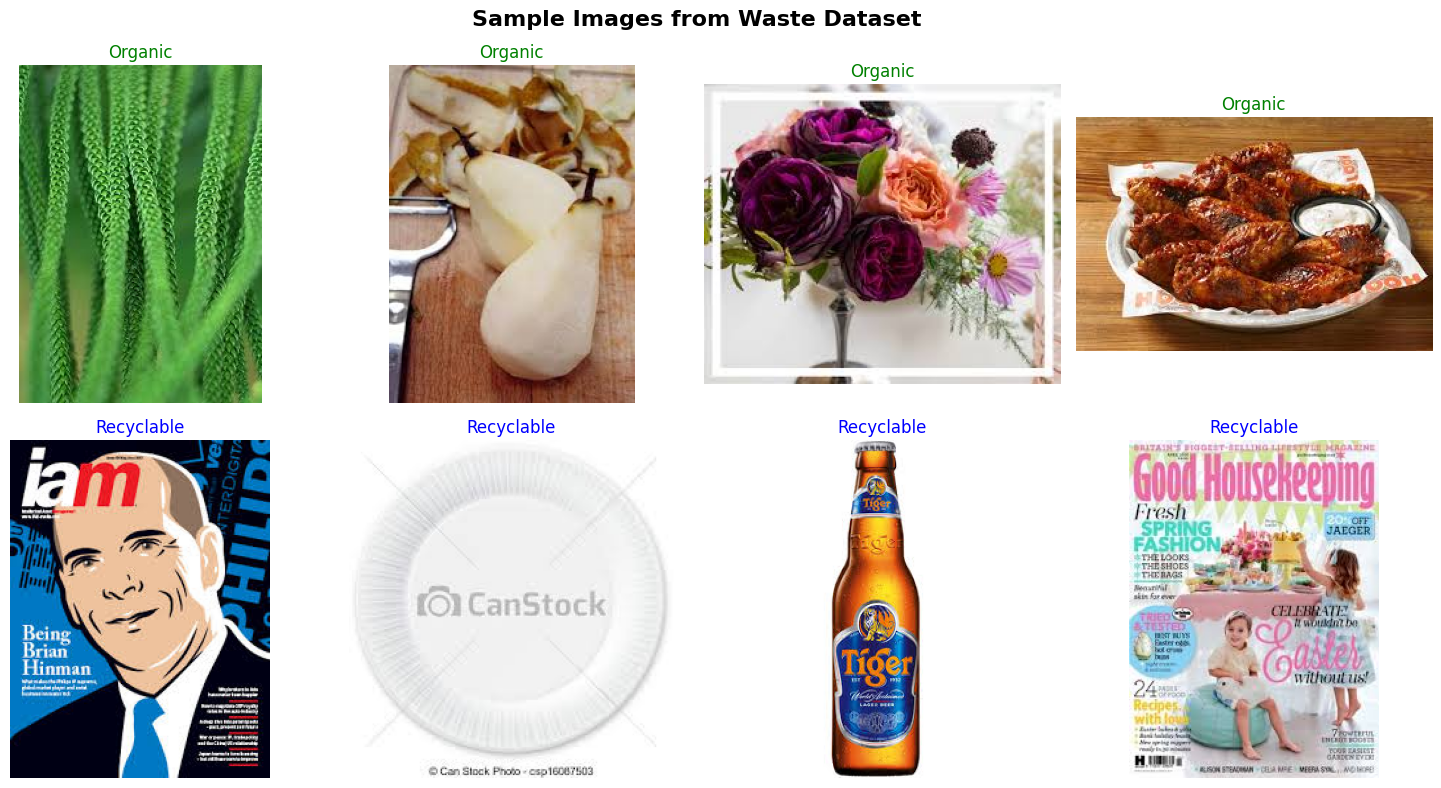

In [11]:
# Function to display sample images
def display_sample_images(train_path, num_samples=8):
    """Display sample images from each category"""
    fig, axes = plt.subplots(2, 4, figsize=(15, 8))
    fig.suptitle('Sample Images from Waste Dataset', fontsize=16, fontweight='bold')

    # Get organic images
    organic_images = os.listdir(train_path + "/O")
    organic_samples = random.sample(organic_images, num_samples//2)

    # Get recycle images
    recycle_images = os.listdir(train_path + "/R")
    recycle_samples = random.sample(recycle_images, num_samples//2)

    # Plot organic images
    for i, img_name in enumerate(organic_samples):
        img_path = os.path.join(train_path + "/O", img_name)
        img = Image.open(img_path)
        ax = axes[0, i]
        ax.imshow(img)
        ax.set_title("Organic", color='green')
        ax.axis('off')

    # Plot recycle images
    for i, img_name in enumerate(recycle_samples):
        img_path = os.path.join(train_path + "/R", img_name)
        img = Image.open(img_path)
        ax = axes[1, i]
        ax.imshow(img)
        ax.set_title("Recyclable", color='blue')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Display sample images
print("Displaying sample images from training set...")
display_sample_images(train_dir)

# Data Visualization - Distribution Charts

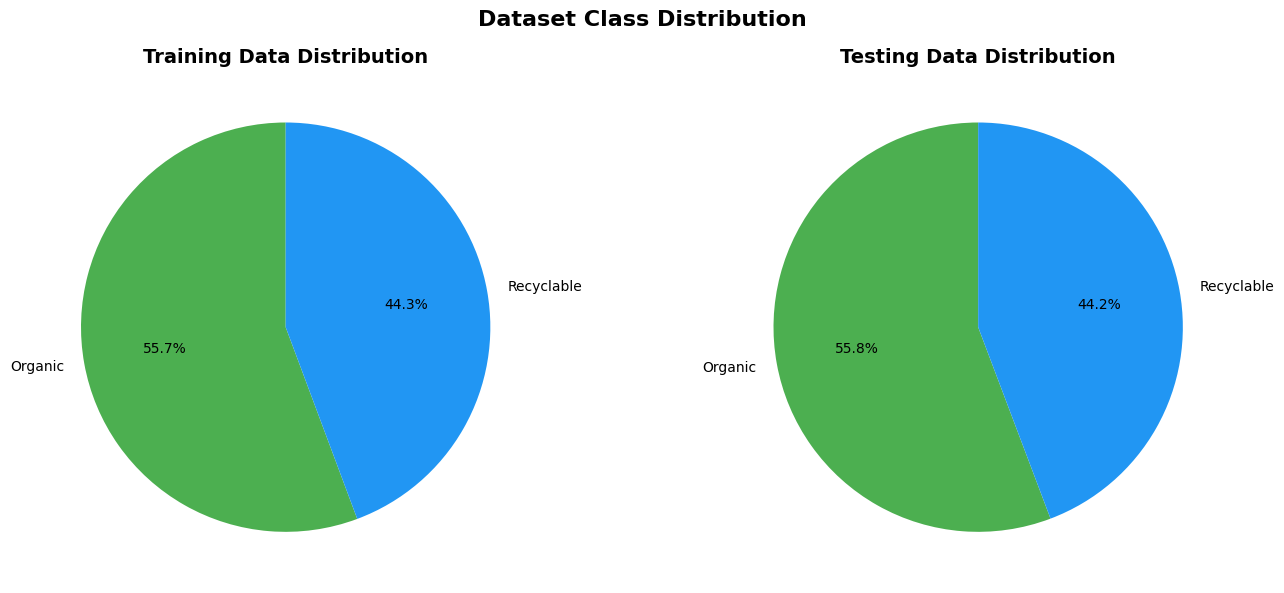

In [12]:
# Create pie chart for data distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Training data distribution
train_counts = [len(train_organic), len(train_recycle)]
train_labels = ['Organic', 'Recyclable']
colors = ['#4CAF50', '#2196F3']

ax1.pie(train_counts, labels=train_labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Training Data Distribution', fontsize=14, fontweight='bold')

# Testing data distribution
test_counts = [len(test_organic), len(test_recycle)]
ax2.pie(test_counts, labels=train_labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Testing Data Distribution', fontsize=14, fontweight='bold')

plt.suptitle('Dataset Class Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

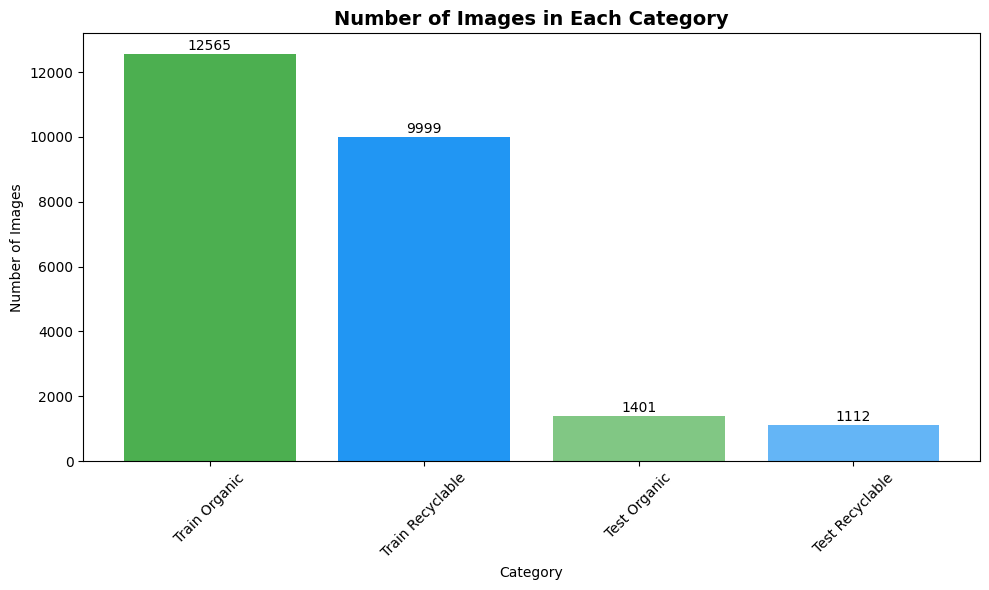

In [13]:
# Bar chart for data distribution
fig, ax = plt.subplots(figsize=(10, 6))
categories = ['Train Organic', 'Train Recyclable', 'Test Organic', 'Test Recyclable']
counts = [len(train_organic), len(train_recycle), len(test_organic), len(test_recycle)]
colors_bar = ['#4CAF50', '#2196F3', '#81C784', '#64B5F6']

bars = ax.bar(categories, counts, color=colors_bar)
ax.set_title('Number of Images in Each Category', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Images')
ax.set_xlabel('Category')

# Add count labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 20,
            f'{count}', ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Prepare Data Generators

In [14]:
# Machine learning and deep learning libraries

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
# Image parameters
IMG_HEIGHT = 150
IMG_WIDTH = 150
BATCH_SIZE = 32

print(f"Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"Batch size: {BATCH_SIZE}")


Image size: 150x150
Batch size: 32


In [16]:
# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0,1]
    rotation_range=20,        # Random rotation up to 20 degrees
    width_shift_range=0.2,    # Random horizontal shift
    height_shift_range=0.2,   # Random vertical shift
    shear_range=0.2,          # Shear transformation
    zoom_range=0.2,           # Random zoom
    horizontal_flip=True,     # Random horizontal flip
    fill_mode='nearest'       # Fill missing pixels
)

In [17]:
# Validation/test data generator (only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

In [18]:
print("Creating training data generator...")
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',  # Binary classification (Organic vs Recyclable)
    classes=['O', 'R'],   # Folder names correspond to classes
    color_mode='rgb',     # Color images
    shuffle=True
)

Creating training data generator...
Found 22564 images belonging to 2 classes.


In [19]:
print("Creating testing data generator...")
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['O', 'R'],
    color_mode='rgb',
    shuffle=False  # Don't shuffle test data
)

Creating testing data generator...
Found 2513 images belonging to 2 classes.


In [20]:
# Check class indices
print(f"Class indices: {train_generator.class_indices}")
print("Note: 0 = Organic, 1 = Recyclable")

Class indices: {'O': 0, 'R': 1}
Note: 0 = Organic, 1 = Recyclable


# Visulalize Augmented Images

Displaying augmented images...


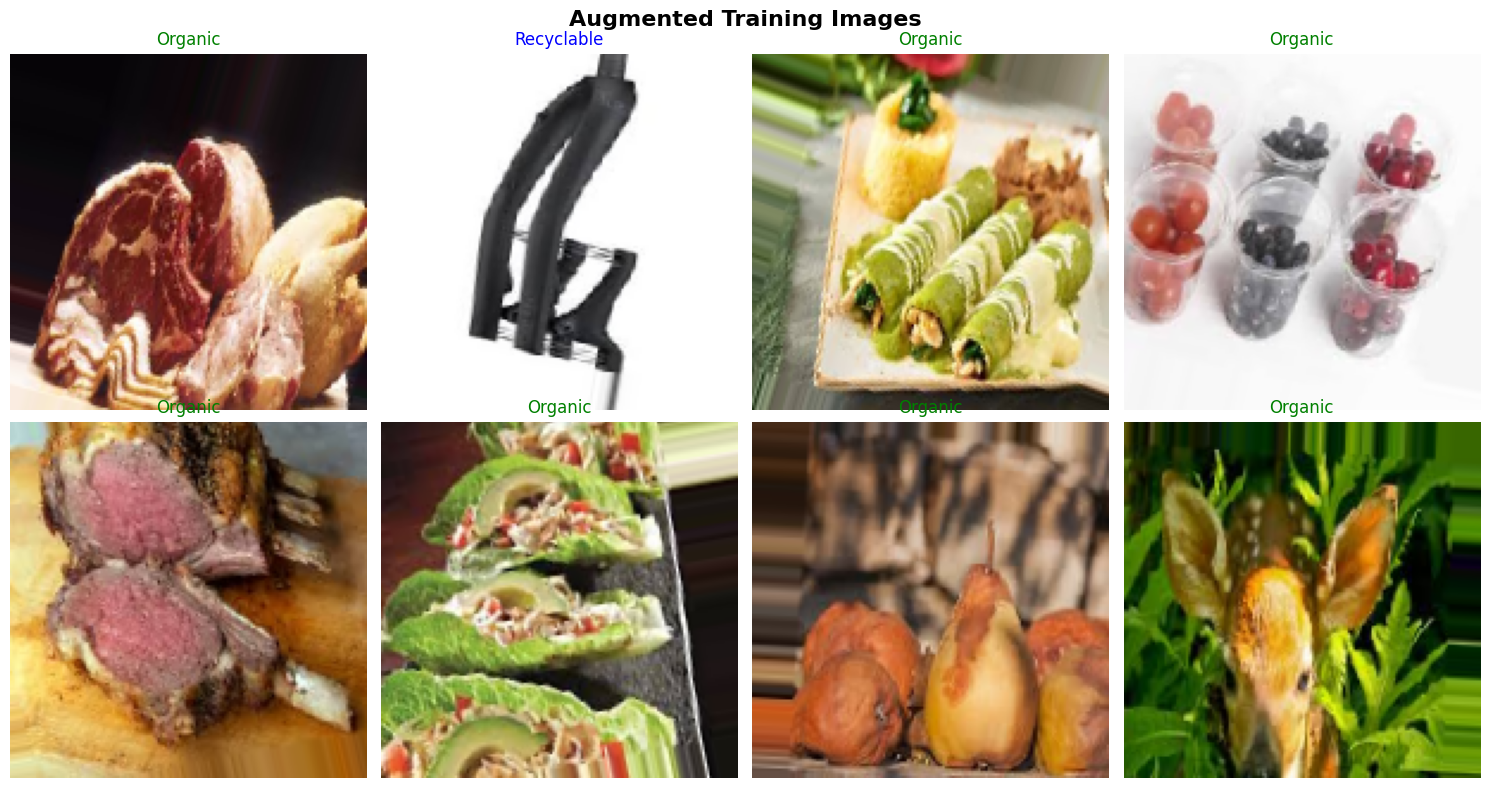

In [21]:
# Get a batch of augmented images
print("Displaying augmented images...")
augmented_images, augmented_labels = next(train_generator)

fig, axes = plt.subplots(2, 4, figsize=(15, 8))
fig.suptitle('Augmented Training Images', fontsize=16, fontweight='bold')

for i in range(8):
    ax = axes[i//4, i%4]
    ax.imshow(augmented_images[i])
    label = "Organic" if augmented_labels[i] == 0 else "Recyclable"
    color = "green" if augmented_labels[i] == 0 else "blue"
    ax.set_title(label, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Build CNN Model

In [22]:
# Clear any previous models
keras.backend.clear_session()

In [23]:
print("Creating Convolutional Neural Network (CNN) model...")

# Build the CNN model
model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third convolutional block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fourth convolutional block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten layer to connect to dense layers
    layers.Flatten(),

    # Dropout to prevent overfitting
    layers.Dropout(0.5),

    # Dense layers
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')  # Binary classification output
])


Creating Convolutional Neural Network (CNN) model...


In [24]:
# Display model summary
print("Model Architecture:")
model.summary()

Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Compile the model
print("Compiling model...")
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)


Compiling model...


# Train the Model

In [26]:
# Define callbacks
callbacks = [
    # Early stopping to prevent overfitting
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    # Reduce learning rate when validation loss plateaus
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=0.00001,
        verbose=1
    )
]

In [27]:
# Calculate steps per epoch
train_steps = train_generator.samples // BATCH_SIZE
validation_steps = test_generator.samples // BATCH_SIZE

In [28]:
print(f"Training Steps per Epoch: {train_steps}")
print(f"Validation Steps per Epoch: {validation_steps}")

Training Steps per Epoch: 705
Validation Steps per Epoch: 78


In [29]:
# Train the model
print("Starting model training...")
EPOCHS = 20

history = model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    epochs=EPOCHS,
    validation_data=test_generator,
    validation_steps=validation_steps,
    callbacks=callbacks,
    verbose=1
)

print("Model training completed!")


Starting model training...
Epoch 1/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 217s 297ms/step - accuracy: 0.7587 - loss: 0.4938 - precision: 0.7522 - recall: 0.6758 - val_accuracy: 0.8690 - val_loss: 0.3510 - val_precision: 0.8887 - val_recall: 0.8018 - learning_rate: 0.0010
Epoch 2/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9375 - loss: 0.3012 - precision: 1.0000 - recall: 0.8667 - val_accuracy: 0.8674 - val_loss: 0.3509 - val_precision: 0.8914 - val_recall: 0.7945 - learning_rate: 0.0010
Epoch 3/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 146s 207ms/step - accuracy: 0.8198 - loss: 0.4139 - precision: 0.8161 - recall: 0.7699 - val_accuracy: 0.8834 - val_loss: 0.2865 - val_precision: 0.9389 - val_recall: 0.7854 - learning_rate: 0.0010
Epoch 4/20
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9062 - loss: 0.2327 - precision: 1.0000 - recall: 0.7273 - val_accuracy: 0.8766 - val_loss: 0.2984 - val_precision: 0.9560 - val_recall: 0.7534 - learning_rate: 0.0010
Epoch 5/20
705/705 ━━━━━━━━━━

# Visualize Training History

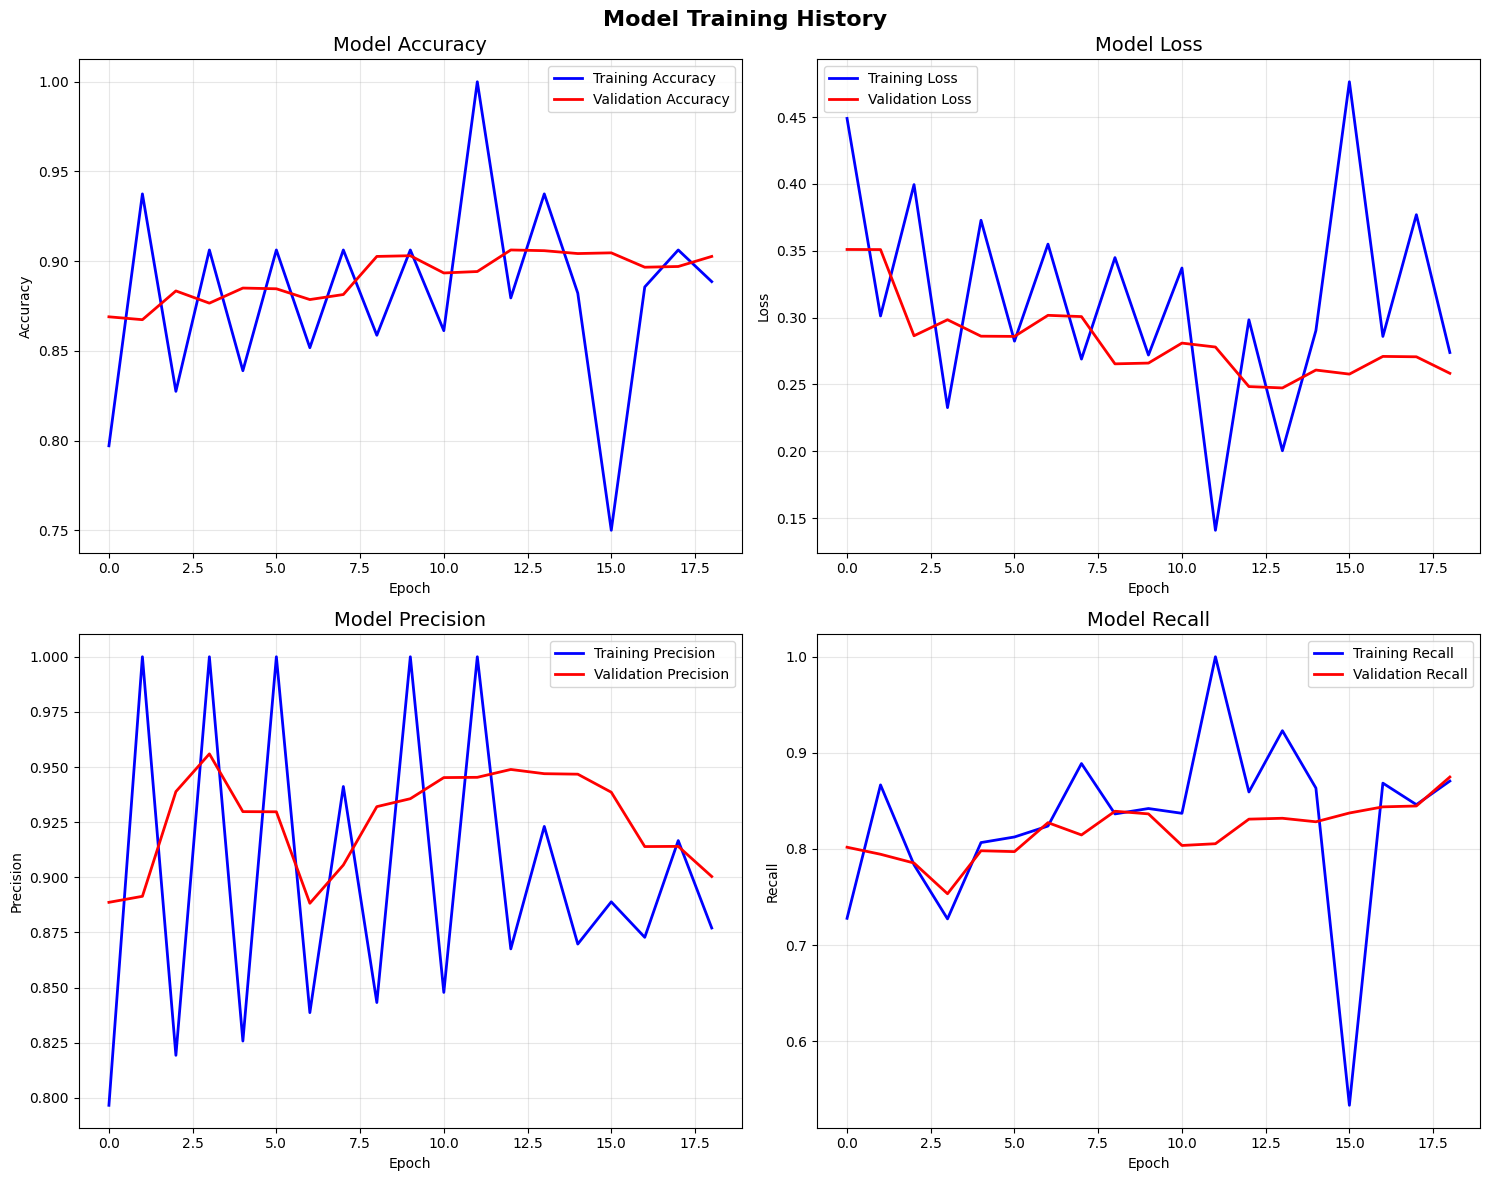

In [30]:
# Create figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model Training History', fontsize=16, fontweight='bold')

# Plot accuracy
axes[0, 0].plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
axes[0, 0].set_title('Model Accuracy', fontsize=14)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot loss
axes[0, 1].plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', color='red', linewidth=2)
axes[0, 1].set_title('Model Loss', fontsize=14)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot precision
if 'precision' in history.history:
    axes[1, 0].plot(history.history['precision'], label='Training Precision', color='blue', linewidth=2)
    axes[1, 0].plot(history.history['val_precision'], label='Validation Precision', color='red', linewidth=2)
    axes[1, 0].set_title('Model Precision', fontsize=14)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Precision')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Plot recall
if 'recall' in history.history:
    axes[1, 1].plot(history.history['recall'], label='Training Recall', color='blue', linewidth=2)
    axes[1, 1].plot(history.history['val_recall'], label='Validation Recall', color='red', linewidth=2)
    axes[1, 1].set_title('Model Recall', fontsize=14)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Evaluate the Model

In [31]:
# Evaluate on test data
print("Evaluating model on test data...")
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator, verbose=0)

print(f"Test Results:")
print(f"  - Loss: {test_loss:.4f}")
print(f"  - Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"  - Precision: {test_precision:.4f}")
print(f"  - Recall: {test_recall:.4f}")

Evaluating model on test data...
Test Results:
  - Loss: 0.2485
  - Accuracy: 0.9049 (90.49%)
  - Precision: 0.9477
  - Recall: 0.8309


In [32]:
# Calculate F1-Score
if test_precision + test_recall > 0:
    f1_score = 2 * (test_precision * test_recall) / (test_precision + test_recall)
    print(f"F1-Score: {f1_score:.4f}")

F1-Score: 0.8855


In [33]:
# Get predictions
print("Generating predictions...")
test_generator.reset()  # Reset generator to start from beginning
predictions = model.predict(test_generator, verbose=0)
predicted_classes = (predictions > 0.5).astype("int32").flatten()


Generating predictions...


In [34]:
# Get true labels
true_classes = test_generator.classes
true_classes

array([0, 0, 0, ..., 1, 1, 1], dtype=int32)

# Confusion Matrix

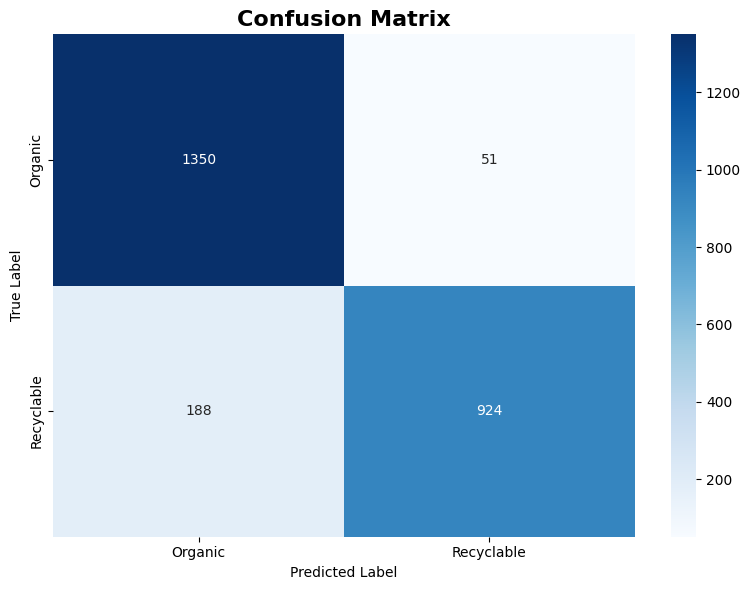

In [35]:
# Create confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Organic', 'Recyclable'],
            yticklabels=['Organic', 'Recyclable'])
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

In [36]:
# Calculate metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

print("Detailed Metrics from Confusion Matrix:")
print(f"  - True Positives (TP): {tp}")
print(f"  - True Negatives (TN): {tn}")
print(f"  - False Positives (FP): {fp}")
print(f"  - False Negatives (FN): {fn}")
print(f"  - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"  - Precision: {precision:.4f}")
print(f"  - Recall (Sensitivity): {recall:.4f}")
print(f"  - Specificity: {specificity:.4f}")

Detailed Metrics from Confusion Matrix:
  - True Positives (TP): 924
  - True Negatives (TN): 1350
  - False Positives (FP): 51
  - False Negatives (FN): 188
  - Accuracy: 0.9049 (90.49%)
  - Precision: 0.9477
  - Recall (Sensitivity): 0.8309
  - Specificity: 0.9636


In [37]:
# Generate classification report
class_names = ['Organic', 'Recyclable']
report = classification_report(true_classes, predicted_classes,
                               target_names=class_names, digits=4)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

     Organic     0.8778    0.9636    0.9187      1401
  Recyclable     0.9477    0.8309    0.8855      1112

    accuracy                         0.9049      2513
   macro avg     0.9127    0.8973    0.9021      2513
weighted avg     0.9087    0.9049    0.9040      2513



# Visualize Predictions

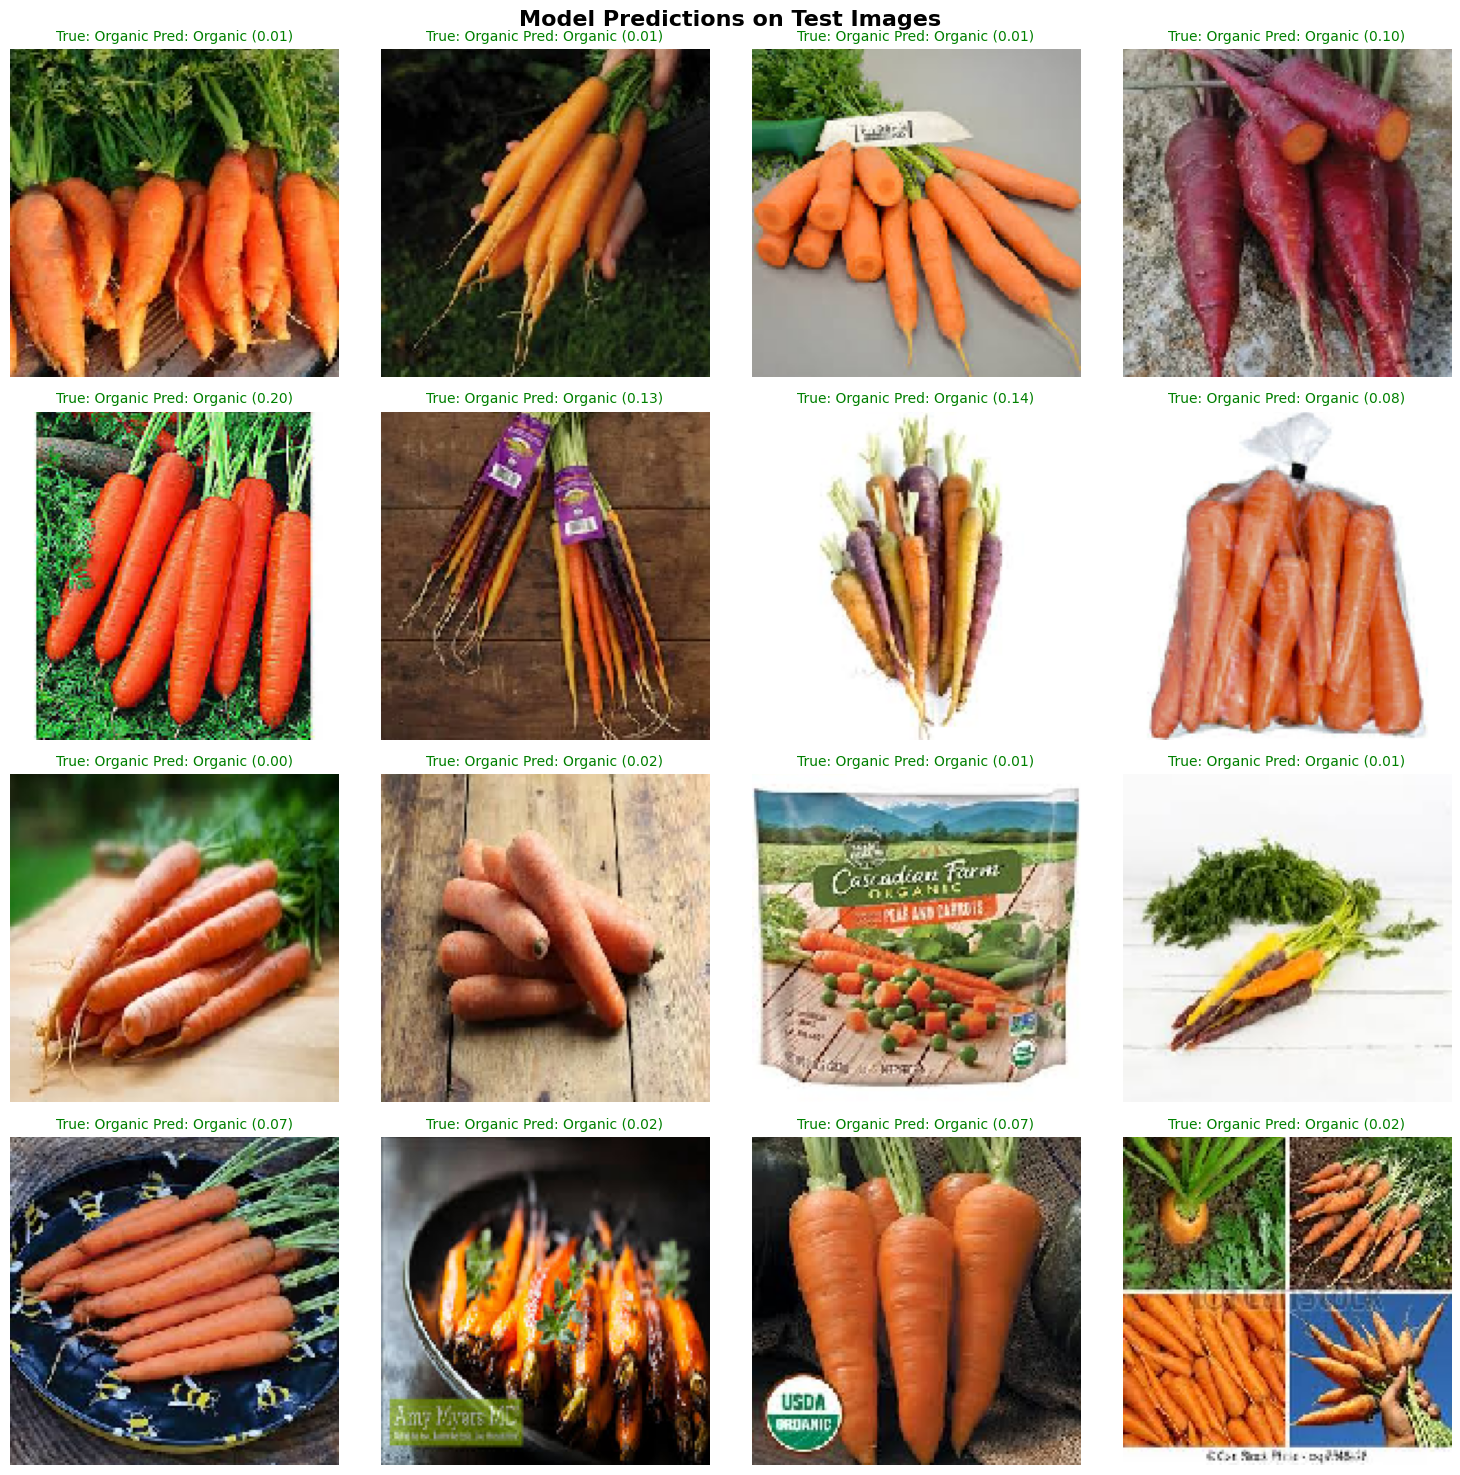

In [38]:
# Get a batch of test images
test_generator.reset()
test_images, test_labels = next(test_generator)
test_predictions = model.predict(test_images, verbose=0)

# Display predictions
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
fig.suptitle('Model Predictions on Test Images', fontsize=16, fontweight='bold')

for i in range(16):
    ax = axes[i//4, i%4]

    # Display image
    ax.imshow(test_images[i])

    # Get prediction
    pred_prob = test_predictions[i][0]
    pred_class = "Recyclable" if pred_prob > 0.5 else "Organic"
    true_class = "Recyclable" if test_labels[i] == 1 else "Organic"

    # Set color based on correctness
    color = "green" if pred_class == true_class else "red"

    # Set title
    ax.set_title(f"True: {true_class} Pred: {pred_class} ({pred_prob:.2f})",
                 color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Save the Model

In [39]:
# Create models directory if it doesn't exist
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

# Save the model in different formats
model_name = "waste_classification_model"

print("=" * 50)
print("SAVING MODEL IN KERAS 2 FORMAT")
print("=" * 50)

# Option 1: Save as Keras 3 format (.keras) - RECOMMENDED
keras_model_path = os.path.join(model_dir, f"{model_name}.keras")
model.save(keras_model_path)
print(f"✓ Model saved as Keras 3 format: {keras_model_path}")

# Option 2: Save as legacy H5 format (not recommended, but for compatibility)
try:
    h5_model_path = os.path.join(model_dir, f"{model_name}.h5")
    model.save(h5_model_path)
    print(f"✓ Model saved as legacy H5 format: {h5_model_path}")
except Exception as e:
    print(f"⚠ H5 format warning: {e}")
    print("Note: H5 format is legacy. Using .keras format is recommended.")

# Save model architecture as JSON
try:
    model_json = model.to_json()
    json_path = os.path.join(model_dir, f"{model_name}_architecture.json")
    with open(json_path, "w") as json_file:
        json_file.write(model_json)
    print(f"✓ Model architecture saved as JSON: {json_path}")
except Exception as e:
    print(f"⚠ Could not save architecture as JSON: {e}")

# Save model weights separately
try:
    weights_path = os.path.join(model_dir, f"{model_name}_weights.keras")
    model.save_weights(weights_path)
    print(f"✓ Model weights saved: {weights_path}")
except Exception as e:
    print(f"⚠ Could not save weights separately: {e}")

print("" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print("✅ Use the .keras file for Keras 3 applications")
print("✅ Use the savedmodel folder for TensorFlow Serving")
print("✅ The .h5 file is legacy format (not recommended)")

SAVING MODEL IN KERAS 2 FORMAT


✓ Model saved as Keras 3 format: saved_models/waste_classification_model.keras
✓ Model saved as legacy H5 format: saved_models/waste_classification_model.h5
✓ Model architecture saved as JSON: saved_models/waste_classification_model_architecture.json
⚠ Could not save weights separately: The filename must end in `.weights.h5`. Received: filepath=saved_models/waste_classification_model_weights.keras
SUMMARY
✅ Use the .keras file for Keras 3 applications
✅ Use the savedmodel folder for TensorFlow Serving
✅ The .h5 file is legacy format (not recommended)


# Overall Summary

Model Training Summary:
         Metric  Value
Training Images  22564
 Testing Images   2513
 Model Accuracy 0.9049
Model Precision 0.9477
   Model Recall 0.8309
     Model Loss 0.2485


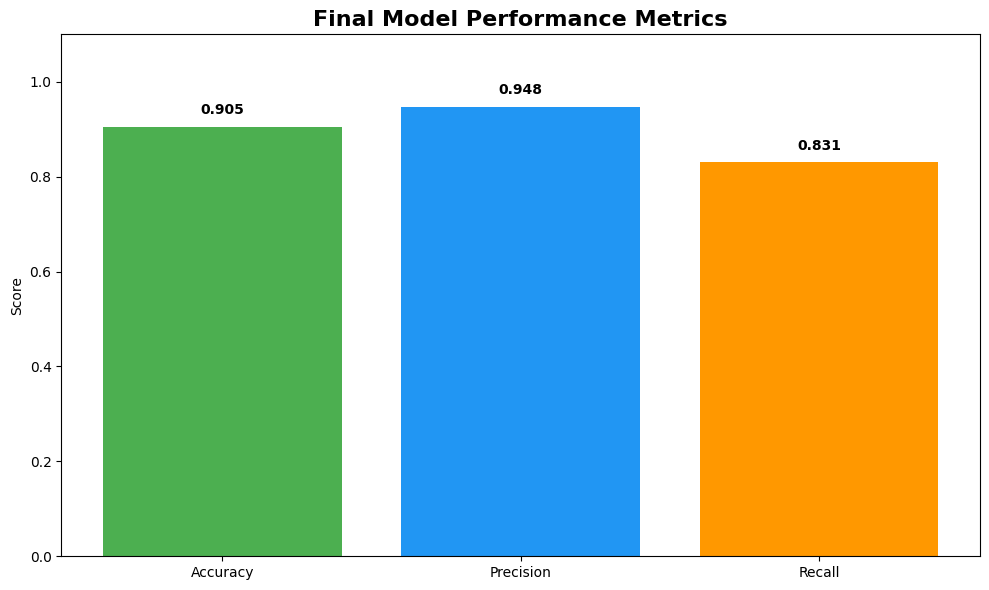

In [40]:
# Create a summary DataFrame
summary_data = {
    'Metric': ['Training Images', 'Testing Images', 'Model Accuracy',
               'Model Precision', 'Model Recall', 'Model Loss'],
    'Value': [f"{train_generator.samples}", f"{test_generator.samples}",
              f"{test_accuracy:.4f}", f"{test_precision:.4f}",
              f"{test_recall:.4f}", f"{test_loss:.4f}"]
}

summary_df = pd.DataFrame(summary_data)
print("Model Training Summary:")
print("=" * 40)
print(summary_df.to_string(index=False))
print("=" * 40)

# Create a final visualization
fig, ax = plt.subplots(figsize=(10, 6))
metrics = ['Accuracy', 'Precision', 'Recall']
values = [test_accuracy, test_precision, test_recall]
colors = ['#4CAF50', '#2196F3', '#FF9800']

bars = ax.bar(metrics, values, color=colors)
ax.set_title('Final Model Performance Metrics', fontsize=16, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bar, value in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Model Prediction

In [41]:
model_path = '/content/saved_models/waste_classification_model.h5'
model = tf.keras.models.load_model(model_path)
print("Model loaded successfully.")

Model loaded successfully.


In [42]:
def predict_waste_type(image_path):
    # Dimensions must match your training (150x150)
    img_height = 150
    img_width = 150

    # Load and preprocess the image
    # target_size automatically resizes it to 150x150
    img = load_img(image_path, target_size=(img_height, img_width))

    # Convert to array and normalize (scale 0-1)
    img_array = img_to_array(img)
    img_array = img_array / 255.0

    # Expand dimensions to fit the model input (1, 150, 150, 3)
    img_batch = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_batch)
    probability = prediction[0][0]

    # Determine class
    if probability > 0.5:
        label = "Recyclable"
        confidence = probability
    else:
        label = "Organic"
        confidence = 1 - probability

    # Display the image and result
    plt.figure(figsize=(6, 6))
    plt.imshow(load_img(image_path)) # Show original image
    plt.axis('off')
    plt.title(f"Prediction: {label}\nConfidence: {confidence*100:.2f}%", fontsize=14, color='blue')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 700ms/step


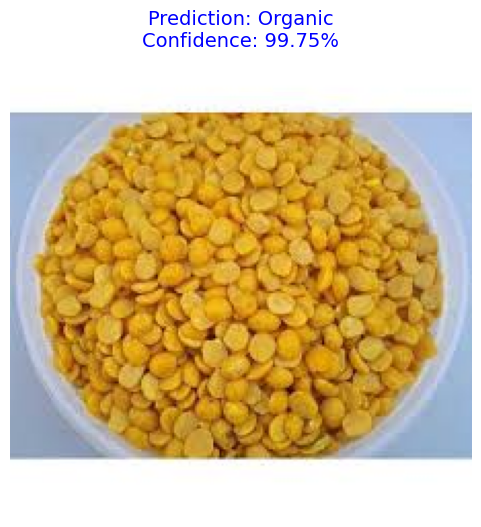

In [43]:
predict_waste_type("/content/sample.jpg")